# Figure 6 — Detection beyond MER (injection truth) (injection truth)

The detection head is a CenterNet on the **frozen** foundation's fused 10-band bottleneck
(`vis_peak` labels — chosen over SEP-relabel and StemCenterNet by a head bake-off on
injection truth). This figure makes the paper's claim with the catalogue-independent
**source-recycling injection** metric, not MER agreement:

- **(a) Depth** — point-source completeness vs injected VIS mag; 50% depth is well past
  MER's catalogue turnover, i.e. we detect real sources MER's VIS-driven catalogue misses.
- **(b) Multi-band gain** — all-10-band vs VIS-only injection: the shaded gap is what the
  foundation's band fusion buys over a VIS-only detector (≈0.5 mag deeper).
- **(c) Where sensitivity comes from** — inject into one instrument subset at a time:
  NISP-only recovers sources (a high-z optical-dropout proxy) that a VIS catalogue cannot,
  while Rubin-only ≈0 confirms the detector is Euclid-anchored.

`REGEN` runs the injection eval (GPU) and caches to `_fig5_injection_cache.pkl`; the plot
cell loads it. Saves `paper/figures/fig5_detection.png`.

In [1]:
import sys, pickle
from pathlib import Path
import numpy as np

def find_repo_root(s=None):
    s=(s or Path.cwd()).resolve()
    for c in [s,*s.parents]:
        if (c/'models').exists() and (c/'data').exists(): return c
    raise FileNotFoundError('repo root')
REPO=find_repo_root(); NB=Path.cwd()
for p in [REPO/'models',REPO/'models'/'detection',REPO/'models'/'astrometry2']:
    if str(p) not in sys.path: sys.path.insert(0,str(p))
CACHE=NB/'_fig6_injection_cache.pkl'
OUT=REPO/'paper'/'figures'/'fig6_injection.png'
MER_FITS=REPO/'data'/'edf_s_ood'/'catalogs_compact'/'mer_FINAL_q1_ECDFS_footprint.fits'

# Detection head: full 200-tile CenterNet vis_peak round-1 (paper head; training complete).
DET_CKPT = REPO/'checkpoints'/'centernet_v10_vispeak_r1_full'/'centernet_best.pt'
ENC=REPO/'models'/'checkpoints'/'jaisp_v10_warmstart'/'checkpoint_best.pt'
CONF=0.30
MAGS=(22.5,23.0,23.5,24.0,24.5,25.0,25.5,26.0,26.5)
N_PER_MAG=15
EVAL_STEMS=(REPO/'data'/'bakeoff_eval16_stems.txt').read_text().split()

REGEN = not CACHE.exists()
print(f'detector: {DET_CKPT.parent.name}\nCACHE exists={CACHE.exists()}  REGEN={REGEN}')

detector: centernet_v10_vispeak_r1_full
CACHE exists=True  REGEN=False


In [2]:
if REGEN:
    import torch
    from detection.validation_utils import load_detector, load_mer, eval_injection
    DEV=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    mer=load_mer(str(MER_FITS))
    det,_=load_detector(str(DET_CKPT), str(ENC), device=DEV)
    print('running injection eval (4 modes) ...')
    rec=eval_injection(det, EVAL_STEMS, mer, str(REPO/'data'/'euclid_tiles_200'),
                       str(REPO/'data'/'rubin_tiles_200'), DEV,
                       modes=('all','vis','nisp','rubin'),
                       target_mags=MAGS, n_per_mag=N_PER_MAG, conf=CONF)
    # MER clean-catalogue VIS magnitude turnover (effective depth proxy)
    mag=np.asarray(mer['cMAG']); mag=mag[np.isfinite(mag)]
    h,edges=np.histogram(mag,bins=np.arange(18,28,0.25)); cen=0.5*(edges[:-1]+edges[1:])
    mer_turnover=float(cen[np.argmax(h)])
    pickle.dump(dict(rec=rec,mags=list(MAGS),mer_turnover=mer_turnover,
                     det=DET_CKPT.parent.name,conf=CONF,n_per_mag=N_PER_MAG,
                     n_tiles=len(EVAL_STEMS)), open(CACHE,'wb'))
    print('cached ->',CACHE,' MER turnover ~',mer_turnover)
    del det
    if DEV.type=='cuda': torch.cuda.empty_cache()
else:
    print('REGEN skipped (cache present).')

REGEN skipped (cache present).


saved -> /home/shemmati/Work/Projects/JAISP/paper/figures/fig6_injection.png | detector: centernet_v10_vispeak_r1_full | depth all=25.99 vis=25.56


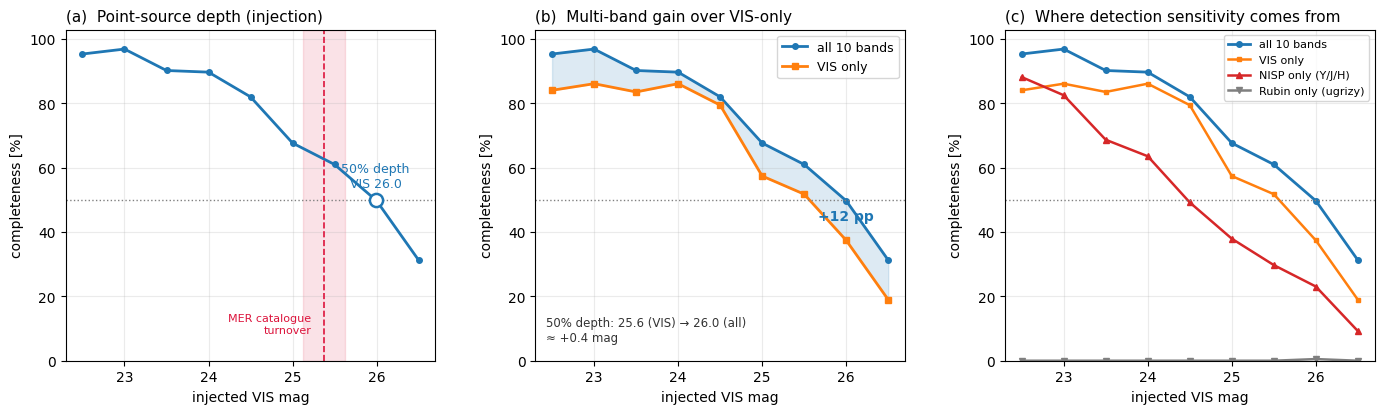

In [3]:
import pickle, numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

c=pickle.load(open(CACHE,'rb')); rec=c['rec']; M=np.array(c['mags']); mt=c['mer_turnover']
def curve(mode): return np.array([100*rec[mode][m][0]/max(rec[mode][m][1],1) for m in c['mags']])
c_all,c_vis,c_nisp,c_rub=curve('all'),curve('vis'),curve('nisp'),curve('rubin')
def d50(comp):
    for i in range(len(M)-1):
        if comp[i]>=50>=comp[i+1]:
            t=(50-comp[i])/((comp[i+1]-comp[i]) or -1e-9); return M[i]+t*(M[i+1]-M[i])
    return M[-1] if comp[-1]>=50 else M[0]
dep_all,dep_vis=d50(c_all),d50(c_vis)

fig=plt.figure(figsize=(14,4.6))
gs=GridSpec(1,3,wspace=0.27,left=0.05,right=0.985,top=0.88,bottom=0.16)
CA,CV,CN,CR='#1f77b4','#ff7f0e','#d62728','#7f7f7f'

# (a) depth
ax=fig.add_subplot(gs[0,0])
ax.plot(M,c_all,'-o',color=CA,lw=2,ms=4,label='all 10 bands')
ax.axhline(50,color='gray',ls=':',lw=1)
ax.axvspan(mt-0.25,mt+0.25,color='crimson',alpha=0.12)
ax.axvline(mt,color='crimson',lw=1.2,ls='--')
ax.text(mt-0.15,8,'MER catalogue\nturnover',color='crimson',fontsize=8,ha='right',va='bottom')
ax.scatter([dep_all],[50],s=90,facecolors='white',edgecolors=CA,zorder=5,lw=1.8)
ax.text(dep_all,54,f'50% depth\nVIS {dep_all:.1f}',color=CA,fontsize=9,ha='center')
ax.set_xlabel('injected VIS mag'); ax.set_ylabel('completeness [%]'); ax.set_ylim(0,103)
ax.set_title('(a)  Point-source depth (injection)',loc='left',fontsize=11); ax.grid(alpha=0.25)

# (b) multi-band gain
ax=fig.add_subplot(gs[0,1])
ax.plot(M,c_all,'-o',color=CA,lw=2,ms=4,label='all 10 bands')
ax.plot(M,c_vis,'-s',color=CV,lw=2,ms=4,label='VIS only')
ax.fill_between(M,c_vis,c_all,color=CA,alpha=0.15)
ax.axhline(50,color='gray',ls=':',lw=1)
gain=c_all-c_vis; jpk=int(np.argmax(gain))
ax.annotate(f'+{gain[jpk]:.0f} pp',xy=(M[jpk],(c_all[jpk]+c_vis[jpk])/2),fontsize=10,
            color=CA,ha='center',fontweight='bold')
ax.text(0.03,0.06,f'50% depth: {dep_vis:.1f} (VIS) → {dep_all:.1f} (all)\n≈ {dep_all-dep_vis:+.1f} mag',
        transform=ax.transAxes,fontsize=8.5,color='#333')
ax.set_xlabel('injected VIS mag'); ax.set_ylabel('completeness [%]'); ax.set_ylim(0,103)
ax.set_title('(b)  Multi-band gain over VIS-only',loc='left',fontsize=11)
ax.legend(fontsize=9,loc='upper right'); ax.grid(alpha=0.25)

# (c) band-subset
ax=fig.add_subplot(gs[0,2])
ax.plot(M,c_all,'-o',color=CA,lw=2,ms=4,label='all 10 bands')
ax.plot(M,c_vis,'-s',color=CV,lw=1.8,ms=3,label='VIS only')
ax.plot(M,c_nisp,'-^',color=CN,lw=1.8,ms=4,label='NISP only (Y/J/H)')
ax.plot(M,c_rub,'-v',color=CR,lw=1.8,ms=4,label='Rubin only (ugrizy)')
ax.axhline(50,color='gray',ls=':',lw=1)
ax.set_xlabel('injected VIS mag'); ax.set_ylabel('completeness [%]'); ax.set_ylim(0,103)
ax.set_title('(c)  Where detection sensitivity comes from',loc='left',fontsize=11)
ax.legend(fontsize=8,loc='upper right'); ax.grid(alpha=0.25)

fig.savefig(OUT,dpi=200,bbox_inches='tight',facecolor='white')
print('saved ->',OUT, '| detector:',c['det'],'| depth all=%.2f vis=%.2f'%(dep_all,dep_vis))
plt.show()